# 1.Youtube GRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [5]:
import pandas as pd
import networkx as nx
from itertools import combinations

# =====================================================
# LOAD YOUTUBE GRAPH DATASET
# =====================================================

df = pd.read_csv(
    "../../data_preprocess/processed_data/graph_data/youtube_graph.csv"
)

print("=" * 60)
print("YOUTUBE GRAPH DATA")
print("=" * 60)

print(df.shape)

YOUTUBE GRAPH DATA
(18130, 30)


In [6]:
import pandas as pd
import numpy as np
import time

overall_start = time.time()

# =====================================================
# 1. GENERATE NODES
# =====================================================
print("Đang tạo Nodes cho YouTube...")
nodes_df = df.copy().rename(columns={"post_id": "Id"})
nodes_df["Label"] = nodes_df["Id"]
nodes_df.to_csv("youtube_node.csv", index=False, encoding='utf-8')

# =====================================================
# 2. GENERATE EDGES (YOUTUBE NICHE & AUTHORITY)
# =====================================================
edges_list = []

sorted_df = df.sort_values(by=['followers'], ascending=True)

# --- A. TOPIC - CLIMATE, GAMING, FINANCE, SCIENCE ---
if 'topic' in sorted_df.columns:
    print("Processing YouTube Niche Clusters (Gaming, Finance, Science...)...")
    for topic, group in sorted_df.groupby('topic'):
        if pd.isna(topic): continue
        ids = group['post_id'].values
        if len(ids) < 2: continue
        
        for i in range(len(ids) - 1):
            if topic in ['Climate', 'Gaming', 'Finance', 'Science', 'Politics']:
                weight = 1.9 
            else:
                weight = 1.2
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": weight, 
                "Relation": "topic_niche"
            })

# --- B. VERIFIED - TOP 2 IMPORTANCE ---
if 'verified' in sorted_df.columns:
    print("Processing YouTube Authority Network...")
    verified_group = sorted_df[sorted_df['verified'] == 1]
    ids = verified_group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.6, 
                "Relation": "authority_link"
            })

# --- C. JAPANESE & LOCATION UNKNOWN ---
if 'language' in sorted_df.columns:
    print("Processing YouTube Language Hubs...")
    for lang, group in sorted_df.groupby('language'):
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            # Ưu tiên tiếng Nhật (Japanese) theo Baseline
            weight = 1.5 if lang == 'Japanese' else 1.0
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": weight, 
                "Relation": "language_cluster"
            })

# --- D. POLLS & COMMUNITY ENGAGEMENT (MEDIA TYPE POLL) ---
if 'media_type' in sorted_df.columns:
    print("Processing YouTube Community Poll Connections...")
    poll_group = sorted_df[sorted_df['media_type'] == 'Poll']
    ids = poll_group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.3, 
                "Relation": "poll_engagement"
            })

# --- E. TOXICITY SCORE ---
if 'toxicity_score' in sorted_df.columns:
    print("Processing YouTube Discussion Intensity...")
    temp_df = sorted_df.copy()
    temp_df['toxic_bins'] = temp_df['toxicity_score'].apply(lambda x: round(x/10)*10)
    for val, group in temp_df.groupby('toxic_bins'):
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 0.9, 
                "Relation": "debate_vibe"
            })

# --- F. USER-ID / CHANNEL ---
print("Processing YouTube Channel Ecosystems...")
for user_id, group in sorted_df.groupby('user_id'):
    ids = group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 2.2, 
                "Relation": "same_channel"
            })

# =====================================================
# 3. CLEAN & EXPORT
# =====================================================
edges_df = pd.DataFrame(edges_list)
if not edges_df.empty:
    edges_df[['Source', 'Target']] = np.sort(edges_df[['Source', 'Target']], axis=1)
    edges_df = edges_df.drop_duplicates(subset=['Source', 'Target', 'Relation'])
    edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

edges_df.to_csv("youtube_edge.csv", index=False, encoding='utf-8')

print(f"\n---YOUTUBE GRAPH ---")
print(f"Nodes: {len(nodes_df):,}")
print(f"Edges: {len(edges_df):,}")
print(f"Time: {round(time.time() - overall_start, 2)}s")

Đang tạo Nodes cho YouTube...
Processing YouTube Niche Clusters (Gaming, Finance, Science...)...
Processing YouTube Authority Network...
Processing YouTube Language Hubs...
Processing YouTube Community Poll Connections...
Processing YouTube Discussion Intensity...
Processing YouTube Channel Ecosystems...

---YOUTUBE GRAPH ---
Nodes: 18,130
Edges: 56,273
Time: 1.57s


In [29]:
import pandas as pd

graph_df = pd.read_csv(
    "youtube-result.csv"
)

print("\n" + "=" * 60)
print("GRAPH FEATURES DATA")
print("=" * 60)

print(graph_df.shape)

print("\nColumns:")
print(graph_df.columns.tolist())


GRAPH FEATURES DATA
(18130, 45)

Columns:
['Id', 'Label', 'platform', 'hour_of_day', 'day_of_week', 'is_weekend', 'user_id', 'followers', 'account_age_days', 'verified', 'topic', 'language', 'content_length', 'media_type', 'num_hashtags', 'sentiment_category', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'toxicity_score', 'location', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'has_media', 'many_hashtags', 'long_content', 'sentiment_intensity', 'high_toxicity', 'popularity', 'Degree', 'Eccentricity', 'closnesscentrality', 'harmonicclosnesscentrality', 'betweenesscentrality', 'Authority', 'Hub', 'modularity_class', 'eigencentrality', 'pageranks', 'componentnumber', 'Weighted Degree', 'clustering', 'triangles']


In [30]:
# SELECT ONLY USEFUL GRAPH FEATURES
# =====================================================

graph_features = graph_df[[
    "Id",
    "Degree", 
    "Authority", 
    "Hub", 
    "pageranks", 
    "modularity_class", 
    "eigencentrality"
]]
graph_features = graph_features.rename(
    columns={
        "Id": "post_id"
    }
)

print("\nGraph Features Shape:")
print(graph_features.shape)



Graph Features Shape:
(18130, 7)


In [31]:
original_df = df.copy()

# =====================================================
# REMOVE DUPLICATES
# =====================================================

original_df = original_df.drop_duplicates(
    subset=["post_id"]
)

In [33]:
# MERGE POST_ID BACK TO TRAIN/TEST
# =====================================================
# We need mapping between rows
# =====================================================

# recreate metadata version
metadata_df = original_df.copy()

remove_cols = [
    
    "timestamp",
    "date",
    "platform",
    "likes",
    "shares",
    "comments",
    "views",
    "total_engagement",
    "engagement_rate_per_1k_followers",
    "viral_coefficient",
    "cross_platform_spread",
    "hours_since_post"
]

existing_remove_cols = [

    col for col in remove_cols
    if col in metadata_df.columns
]

metadata_df = metadata_df.drop(
    columns=existing_remove_cols
)


In [34]:
# =====================================================
# ONE-HOT ENCODING
# =====================================================

categorical_cols = [

    "topic",
    "language",
    "media_type",
    "sentiment_category",
    "location"
]

existing_categorical_cols = [

    col for col in categorical_cols
    if col in metadata_df.columns
]

metadata_df = pd.get_dummies(

    metadata_df,

    columns=existing_categorical_cols,

    drop_first=True
)


In [35]:
# LOAD YOUTUBE TRAIN / TEST
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/youtube_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/youtube_test.csv"
)

print("=" * 60)
print("METADATA DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATASETS
Train Shape: (14504, 56)
Test Shape : (3626, 56)


In [36]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

In [37]:

print("\n" + "="*30)
print("Class distribution in the training set")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nRatio %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("Class distribution in the test set")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nRatio %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


Class distribution in the training set
popularity
0    11602
1     2902
Name: count, dtype: int64

Ratio %:
popularity
0    79.991726
1    20.008274
Name: proportion, dtype: float64

Class distribution in the test set
popularity
0    2901
1     725
Name: count, dtype: int64

Ratio %:
popularity
0    80.005516
1    19.994484
Name: proportion, dtype: float64


In [38]:

negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]

ratio = negative_count / positive_count
print(f"Class imbalance detected! scale_pos_weight = {ratio:.2f}")

Class imbalance detected! scale_pos_weight = 4.00


In [39]:
# FILL MISSING VALUES IN GRAPH FEATURES
# =====================================================

numeric_graph_cols = [
    "Degree", 
    "Authority", 
    "Hub", 
    "pageranks", 
    "modularity_class", 
    "eigencentrality"
]

existing_numeric_cols = [col for col in numeric_graph_cols if col in train_hybrid.columns]

train_hybrid[existing_numeric_cols] = train_hybrid[existing_numeric_cols].fillna(0)
test_hybrid[existing_numeric_cols]  = test_hybrid[existing_numeric_cols].fillna(0)

X_train_cols = train_hybrid.columns
test_hybrid = test_hybrid.reindex(columns=X_train_cols, fill_value=0)

print("\n" + "=" * 60)
print("HYBRID DATASETS - CLEANED & ALIGNED")
print("=" * 60)
print(f"Train Hybrid: {train_hybrid.shape}")
print(f"Test Hybrid : {test_hybrid.shape}")


HYBRID DATASETS - CLEANED & ALIGNED
Train Hybrid: (14504, 62)
Test Hybrid : (3626, 62)


In [40]:
# SAVE HYBRID DATASETS
# =====================================================

train_hybrid.to_csv(
    "youtube_hybrid_train.csv",
    index=False
)

test_hybrid.to_csv(
    "youtube_hybrid_test.csv",
    index=False
)

In [41]:
# =====================================================
# YOUTUBE HYBRID MODEL
# METADATA + GRAPH FEATURES
# =====================================================

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [42]:
# LOAD HYBRID DATASETS
# =====================================================

train_df = pd.read_csv(
    "youtube_hybrid_train.csv"
)

test_df = pd.read_csv(
    "youtube_hybrid_test.csv"
)

print("=" * 60)
print("HYBRID DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

HYBRID DATASETS
Train Shape: (14504, 62)
Test Shape : (3626, 62)


In [43]:
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_df.columns
]

train_df = train_df.drop(
    columns=existing_drop_cols
)

test_df = test_df.drop(
    columns=existing_drop_cols
)

In [44]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_df.drop(
    columns=["popularity"]
)

y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=["popularity"]
)

y_test = test_df["popularity"]

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (14504, 59)
X_test Shape : (3626, 59)


In [45]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.5,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

In [46]:
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING HYBRID MODEL...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [47]:
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [48]:
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [49]:
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      2901
           1       0.55      0.78      0.64       725

    accuracy                           0.83      3626
   macro avg       0.74      0.81      0.76      3626
weighted avg       0.86      0.83      0.84      3626

ROC-AUC  : 0.8970


In [50]:
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[2436  465]
 [ 161  564]]


In [51]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                feature  importance
3             followers    0.173514
57     modularity_class    0.077970
5              verified    0.074114
58      eigencentrality    0.034946
53               Degree    0.034595
55                  Hub    0.030797
56            pageranks    0.023336
44      media_type_Poll    0.023041
54            Authority    0.017242
42     language_Spanish    0.012978
10       toxicity_score    0.012539
21        topic_Climate    0.012082
39    language_Japanese    0.012064
52     location_Unknown    0.011908
8    sentiment_positive    0.011901
27         topic_Gaming    0.011848
4      account_age_days    0.011846
9    sentiment_negative    0.011838
41  language_Portuguese    0.011823
30        topic_Science    0.011772


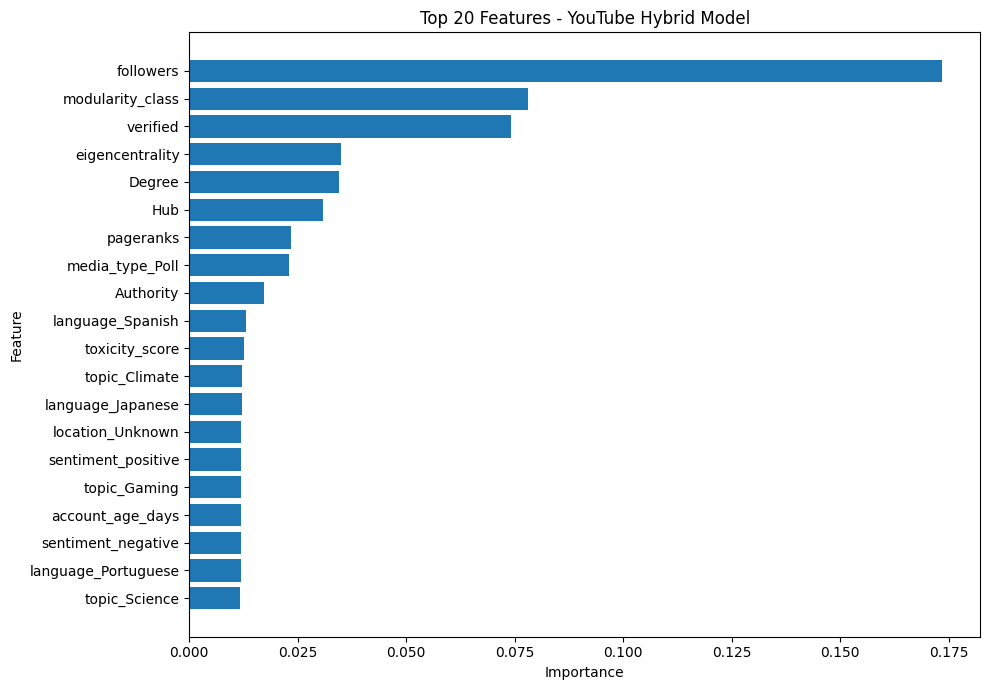

In [53]:
# PLOT TOP FEATURES
# =====================================================
import matplotlib.pyplot as plt

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Features - YouTube Hybrid Model"
)

plt.tight_layout()

plt.show()

# 2. YOUTUBE NODE2VEC

 GRAPH EMBEDDING

In [55]:
import pandas as pd
import os
import networkx as nx

import time

start_time = time.time()

# 1. Just load edges, nodes
# =====================================================
print("Loading Edges file...")
edges_df = pd.read_csv("youtube_edge.csv") 

# 2. Building NetworkX Graph...
# =====================================================
print("Building NetworkX Graph...")
G = nx.from_pandas_edgelist(
    edges_df, 
    source="Source", 
    target="Target", 
    create_using=nx.Graph() 
)

print(f"Graph Created  | Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}")


print("TRAINING NODE2VEC (MULTI-CORE)...")


so_loi_cpu = os.cpu_count()
print(f" Your laptop has {so_loi_cpu} CPU cores. Mobilizing all cores... " )

print("\n" + "=" * 60)
print("TRAINING NODE2VEC (MULTI-CORE UPDATE)...")
print("=" * 60)



Loading Edges file...
Building NetworkX Graph...
Graph Created  | Nodes: 18,130 | Edges: 52,546
TRAINING NODE2VEC (MULTI-CORE)...
 Your laptop has 16 CPU cores. Mobilizing all cores... 

TRAINING NODE2VEC (MULTI-CORE UPDATE)...


In [56]:
from node2vec import Node2Vec
import time

node2vec = Node2Vec(
    G,
    dimensions=8,        
    walk_length=10,      
    num_walks=20,        
    workers=so_loi_cpu,  
    seed=42,
    quiet=False          
)

model = node2vec.fit(
    window=5, 
    min_count=1, 
    batch_words=4     
)

print("\nNode2Vec done")

print(f"\nNode2Vec done after: {round((time.time() - start_time)/60, 2)} minutes ")



Computing transition probabilities:   0%|          | 0/18130 [00:00<?, ?it/s]


Node2Vec done

Node2Vec done after: 6.57 minutes 


In [57]:
# 4.Split and save vectors 
# =====================================================
print("Exporting Embeddings to DataFrame...")

node_ids = list(model.wv.index_to_key)
embeddings = model.wv.vectors

emb_df = pd.DataFrame(embeddings, columns=[f"emb_{i}" for i in range(8)])
emb_df["post_id"] = node_ids 

emb_df = emb_df[emb_df['post_id'].astype(str).str.startswith('YOU')]


emb_df.to_csv("youtube_node2vec_8dims.csv", index=False)
print(f"Successfully saved {len(emb_df)} vectors of Post articles!")

Exporting Embeddings to DataFrame...
Successfully saved 18130 vectors of Post articles!


In [58]:
# YOUTUBE NODE2VEC HYBRID MODEL
# METADATA + NODE2VEC EMBEDDINGS
# =====================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt

In [59]:
# LOAD TRAIN / TEST DATA
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/youtube_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/youtube_test.csv"
)

print("=" * 60)
print("METADATA DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATA
Train Shape: (14504, 56)
Test Shape : (3626, 56)


In [60]:
#LOAD NODE2VEC EMBEDDINGS
# =====================================================

embedding_df = pd.read_csv(
    "youtube_node2vec_8dims.csv"
)

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

print("\nEmbedding Columns:")
print(embedding_df.columns[:10])


NODE2VEC EMBEDDINGS
(18130, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='object')


In [61]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# CHECK MISSING VALUES
# =====================================================

print("\n" + "=" * 60)
print("MISSING EMBEDDINGS CHECK")
print("=" * 60)

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nTrain Missing:")

print(
    train_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

# =====================================================
# FILL MISSING EMBEDDINGS
# =====================================================

train_hybrid[embedding_cols] = train_hybrid[
    embedding_cols
].fillna(0)

test_hybrid[embedding_cols] = test_hybrid[
    embedding_cols
].fillna(0)

# =====================================================
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_hybrid.columns
]

train_hybrid = train_hybrid.drop(
    columns=existing_drop_cols
)

test_hybrid = test_hybrid.drop(
    columns=existing_drop_cols
)


MISSING EMBEDDINGS CHECK

Train Missing:
0.0

Test Missing:
0.0


In [62]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_hybrid.drop(
    columns=["popularity"]
)

y_train = train_hybrid["popularity"]

X_test = test_hybrid.drop(
    columns=["popularity"]
)

y_test = test_hybrid["popularity"]

print("\n" + "=" * 60)
print("FINAL DATA")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)



FINAL DATA
X_train: (14504, 61)
X_test : (3626, 61)


In [63]:
# =====================================================
# XGBOOST MODEL

from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    
    scale_pos_weight=ratio,      
    
    n_estimators=300,            
    learning_rate=0.05,          
    max_depth=5,                
    subsample=0.8,               
    colsample_bytree=0.5,        
    colsample_bylevel=0.5,
    reg_alpha=1.0,               
    reg_lambda=2.0,              
    random_state=42,
    n_jobs=-1
)
# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING NODE2VEC HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Training completed ")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

# =====================================================
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


TRAINING NODE2VEC HYBRID MODEL...
Training completed 


In [64]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      2901
           1       0.54      0.79      0.64       725

    accuracy                           0.82      3626
   macro avg       0.74      0.81      0.76      3626
weighted avg       0.86      0.82      0.83      3626

ROC-AUC  : 0.8978


In [65]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                feature  importance
3             followers    0.255810
5              verified    0.152047
58                emb_5    0.018519
59                emb_6    0.017518
60                emb_7    0.016872
55                emb_2    0.016277
54                emb_1    0.015740
21        topic_Climate    0.015725
57                emb_4    0.014081
56                emb_3    0.013651
10       toxicity_score    0.012436
39    language_Japanese    0.011919
53                emb_0    0.011772
38       language_Hindi    0.011624
52     location_Unknown    0.011265
9    sentiment_negative    0.011238
18  sentiment_intensity    0.011195
6        content_length    0.011080
4      account_age_days    0.010981
42     language_Spanish    0.010859


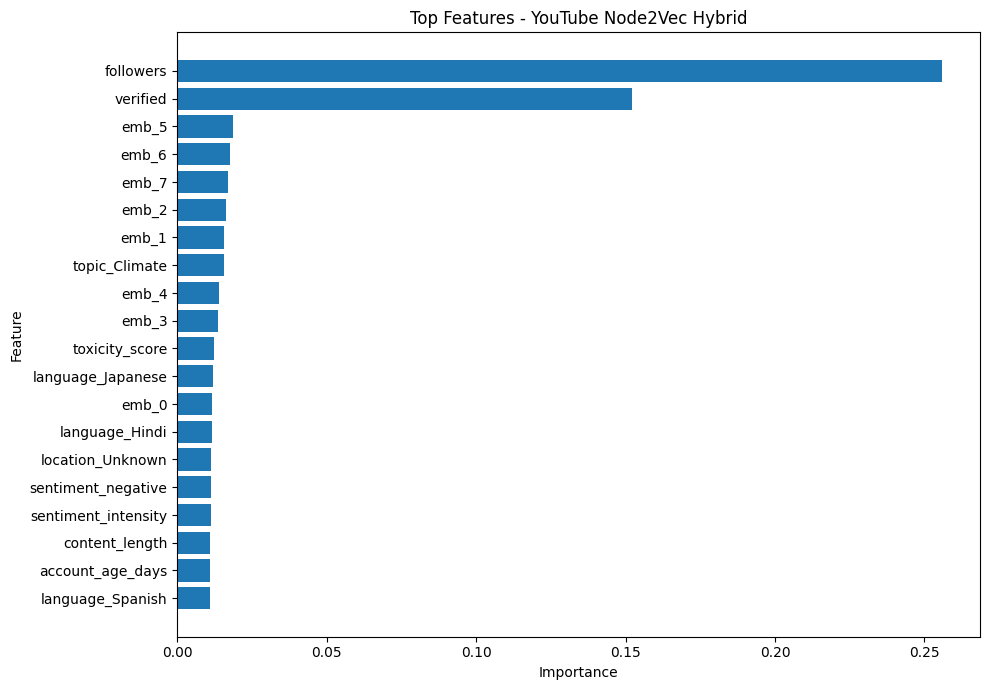

In [66]:
# =====================================================

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features - YouTube Node2Vec Hybrid"
)

plt.tight_layout()

plt.show()

# 3. Youtube graph + Node2vector

In [67]:
selected_n2v = ["emb_2", "emb_7", "emb_4", "emb_0", "emb_6", "emb_5", "emb_3", "emb_1"]

embedding_df_filtered = embedding_df[["post_id"] + [c for c in selected_n2v if c in embedding_df.columns]]

print("---  Done to filter Embeddings  ---")
print(f"Using columns: {embedding_df_filtered.columns.tolist()}")

---  Done to filter Embeddings  ---
Using columns: ['post_id', 'emb_2', 'emb_7', 'emb_4', 'emb_0', 'emb_6', 'emb_5', 'emb_3', 'emb_1']


In [68]:
train_df = pd.read_csv(
    "youtube_hybrid_train.csv"
)

test_df = pd.read_csv(
    "youtube_hybrid_test.csv"
)

print("=" * 60)
print("GRAPH HYBRID DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# =====================================================
# LOAD NODE2VEC EMBEDDINGS
# =====================================================

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

# =====================================================
# CHECK EMBEDDING KEY
# =====================================================

print("\nEmbedding Columns:")
print(embedding_df.columns)


GRAPH HYBRID DATA
Train Shape: (14504, 62)
Test Shape : (3626, 62)

NODE2VEC EMBEDDINGS
(18130, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='object')


In [69]:
# 2. MERGE INTO DATA HYBRID 
# =====================================================
# Merge into Train set
train_final = train_df.merge(embedding_df_filtered, on="post_id", how="left")

# Merge into Test set
test_final = test_df.merge(embedding_df_filtered, on="post_id", how="left")

print(f"\n---  Done merging Embeddings  ---")
print(f"Train Shape: {train_final.shape} | Test Shape: {test_final.shape}")


---  Done merging Embeddings  ---
Train Shape: (14504, 70) | Test Shape: (3626, 70)


In [70]:
# 3. Process missing values
actual_emb_cols = [col for col in train_final.columns if col.startswith("emb_")]

print(f"\n Checking missing values for {len(actual_emb_cols)} embedding columns...")

train_final[actual_emb_cols] = train_final[actual_emb_cols].fillna(0)
test_final[actual_emb_cols] = test_final[actual_emb_cols].fillna(0)

print(f"Missing values after fill: {train_final[actual_emb_cols].isnull().sum().sum()}")


 Checking missing values for 8 embedding columns...
Missing values after fill: 0


In [71]:
# =====================================================
# 4. DROP COLUMNS (POST_ID, USER_ID)
# =====================================================
drop_cols = ["post_id", "user_id"]
existing_drop_cols = [col for col in drop_cols if col in train_final.columns]

train_final = train_final.drop(columns=existing_drop_cols)
test_final = test_final.drop(columns=existing_drop_cols)

print(f"\n--- Done ---")
print(f"Final number of features: {train_final.shape[1]} features.")


--- Done ---
Final number of features: 68 features.


In [72]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_final.drop(
    columns=["popularity"]
)

y_train = train_final["popularity"]

X_test = test_final.drop(
    columns=["popularity"]
)

y_test = test_final["popularity"]

print("\n" + "=" * 60)
print("FINAL FEATURE SPACE")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


FINAL FEATURE SPACE
X_train: (14504, 67)
X_test : (3626, 67)


In [73]:
# XGBOOST MODEL
# =====================================================

# XGBOOST MODEL
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.7,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING FINAL YOUTUBE META + GRAPH + EMBEDDING...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("\nTraining completed ")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


TRAINING FINAL YOUTUBE META + GRAPH + EMBEDDING...

Training completed 


In [74]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


In [75]:


# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.84      0.88      2901
           1       0.54      0.77      0.64       725

    accuracy                           0.82      3626
   macro avg       0.74      0.80      0.76      3626
weighted avg       0.86      0.82      0.83      3626

ROC-AUC  : 0.8975


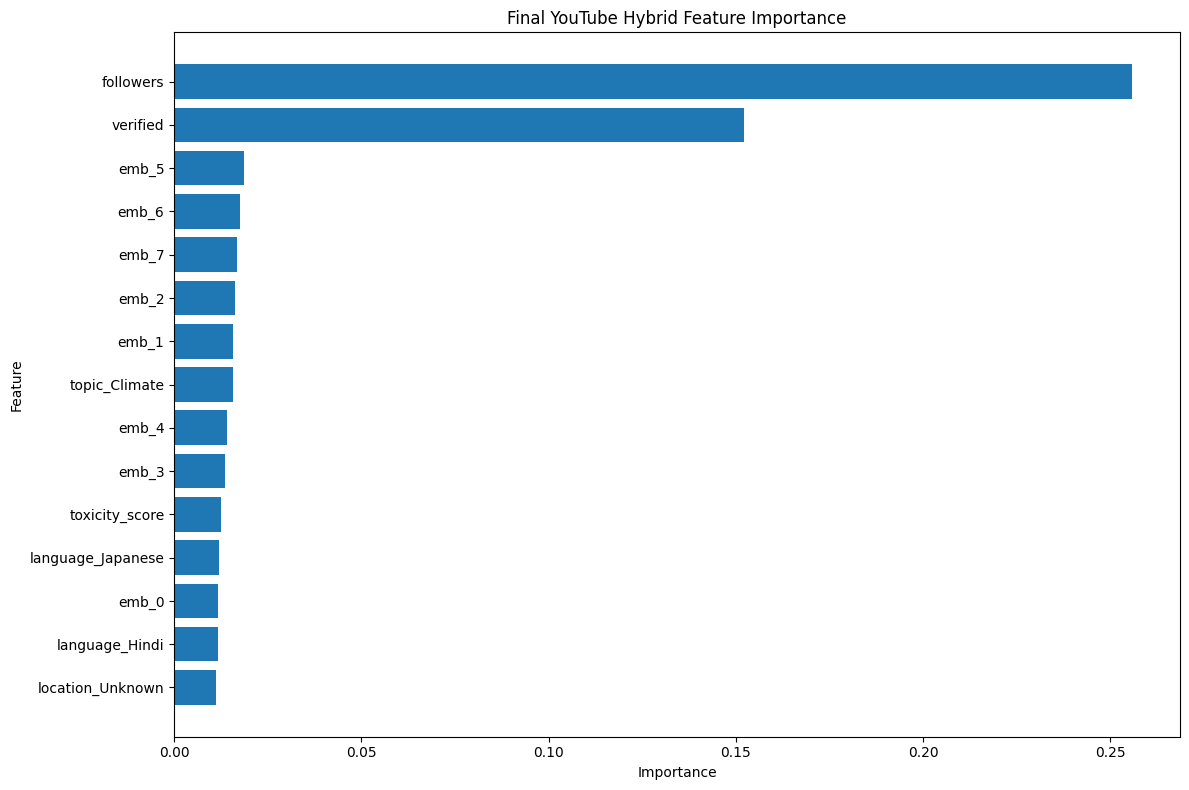

In [76]:
# PLOT FEATURE IMPORTANCE
# =====================================================

top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(12, 8))

plt.barh(

    plot_df["feature"][::-1],

    plot_df["importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Final YouTube Hybrid Feature Importance"
)

plt.tight_layout()

plt.show()